In [1]:
# Produce Shrink Analysis -- QuickMart Inventory System
# Author: Jeffrey Arzu
# Date: June 2026
# Platform: Zerve

# Business Problem:
# Grocery produce departments face significant financial losses from shrink --
# units ordered but never sold due to spoilage, overstock, or damage.
# This analysis examines 90 days of synthetic inventory data modeled after
# real produce department operations to identify which categories drive the
# most loss and which days of the week create the highest shrink risk.

# Dataset: Synthetic data generated in Python using realistic shrink rates
# by produce category and day-of-week patterns observed in grocery retail operations.
# Scope: 15 SKUs across 8 categories, January-March 2024, 1,350 daily records.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import random

random.seed(42)
np.random.seed(42)

START_DATE = date(2024, 1, 1)
DAYS = 90

print("Libraries loaded.")

Libraries loaded.


In [3]:
products = pd.DataFrame([
    {"product_id": "P01", "product_name": "Strawberries", "category": "Berries",      "base_price": 3.99, "shelf_life_days": 4},
    {"product_id": "P02", "product_name": "Blueberries",  "category": "Berries",      "base_price": 4.49, "shelf_life_days": 5},
    {"product_id": "P03", "product_name": "Bananas",      "category": "Tropical",     "base_price": 0.59, "shelf_life_days": 7},
    {"product_id": "P04", "product_name": "Mangoes",      "category": "Tropical",     "base_price": 1.49, "shelf_life_days": 6},
    {"product_id": "P05", "product_name": "Romaine",      "category": "Leafy Greens", "base_price": 2.29, "shelf_life_days": 5},
    {"product_id": "P06", "product_name": "Spinach",      "category": "Leafy Greens", "base_price": 3.49, "shelf_life_days": 4},
    {"product_id": "P07", "product_name": "Tomatoes",     "category": "Vegetables",   "base_price": 1.99, "shelf_life_days": 7},
    {"product_id": "P08", "product_name": "Bell Peppers", "category": "Vegetables",   "base_price": 1.29, "shelf_life_days": 8},
    {"product_id": "P09", "product_name": "Carrots",      "category": "Root Veg",     "base_price": 1.49, "shelf_life_days": 14},
    {"product_id": "P10", "product_name": "Potatoes",     "category": "Root Veg",     "base_price": 0.99, "shelf_life_days": 21},
    {"product_id": "P11", "product_name": "Apples",       "category": "Orchard",      "base_price": 1.29, "shelf_life_days": 14},
    {"product_id": "P12", "product_name": "Oranges",      "category": "Orchard",      "base_price": 0.99, "shelf_life_days": 12},
    {"product_id": "P13", "product_name": "Avocados",     "category": "Specialty",    "base_price": 1.79, "shelf_life_days": 5},
    {"product_id": "P14", "product_name": "Broccoli",     "category": "Vegetables",   "base_price": 1.99, "shelf_life_days": 6},
    {"product_id": "P15", "product_name": "Cilantro",     "category": "Herbs",        "base_price": 0.99, "shelf_life_days": 5},
])

print(f"Products loaded: {len(products)} SKUs across {products['category'].nunique()} categories")
products

Products loaded: 15 SKUs across 8 categories


,product_id,product_name,category,base_price,shelf_life_days
0,P01,Strawberries,Berries,3.99,4
1,P02,Blueberries,Berries,4.49,5
2,P03,Bananas,Tropical,0.59,7
3,P04,Mangoes,Tropical,1.49,6
4,P05,Romaine,Leafy Greens,2.29,5
5,P06,Spinach,Leafy Greens,3.49,4
6,P07,Tomatoes,Vegetables,1.99,7
7,P08,Bell Peppers,Vegetables,1.29,8
8,P09,Carrots,Root Veg,1.49,14
9,P10,Potatoes,Root Veg,0.99,21


In [4]:
SHRINK_RATES = {
    "Berries":      {"base": 0.22, "monday_bump": 0.08},
    "Leafy Greens": {"base": 0.18, "monday_bump": 0.07},
    "Herbs":        {"base": 0.20, "monday_bump": 0.06},
    "Tropical":     {"base": 0.12, "monday_bump": 0.04},
    "Specialty":    {"base": 0.15, "monday_bump": 0.05},
    "Vegetables":   {"base": 0.10, "monday_bump": 0.03},
    "Orchard":      {"base": 0.08, "monday_bump": 0.02},
    "Root Veg":     {"base": 0.04, "monday_bump": 0.01},
}

print("Shrink rates defined.")
for category, rates in SHRINK_RATES.items():
    print(f"  {category:<15} base={rates['base']:.0%}  monday bump=+{rates['monday_bump']:.0%}")

Shrink rates defined.
  Berries         base=22%  monday bump=+8%
  Leafy Greens    base=18%  monday bump=+7%
  Herbs           base=20%  monday bump=+6%
  Tropical        base=12%  monday bump=+4%
  Specialty       base=15%  monday bump=+5%
  Vegetables      base=10%  monday bump=+3%
  Orchard         base=8%  monday bump=+2%
  Root Veg        base=4%  monday bump=+1%


In [5]:
sales_rows = []
shrink_rows = []

for day_offset in range(DAYS):
    current_date = START_DATE + timedelta(days=day_offset)
    day_name = current_date.strftime("%A")
    is_weekend = day_name in ["Saturday", "Sunday"]
    is_monday = day_name == "Monday"

    for _, product in products.iterrows():
        category = product["category"]
        rates = SHRINK_RATES[category]

        base_order = random.randint(30, 80)
        units_ordered = int(base_order * (1.3 if is_weekend else 1.0))

        weekend_multiplier = random.uniform(1.1, 1.25) if is_weekend else 1.0
        units_sold = int(min(units_ordered,
                             random.randint(20, 60) * weekend_multiplier))

        shrink_rate = rates["base"] + (rates["monday_bump"] if is_monday else 0)
        shrink_rate += random.uniform(-0.02, 0.02)
        shrink_rate = max(0, min(shrink_rate, 0.50))

        units_wasted = max(0, int((units_ordered - units_sold) * shrink_rate) +
                           random.randint(0, 3))
        dollar_loss = round(units_wasted * product["base_price"], 2)

        waste_reasons = ["spoilage", "overstock", "damage", "expired"]
        reason_weights = [0.5, 0.3, 0.1, 0.1]

        sales_rows.append({
            "sale_date":   current_date,
            "day_of_week": day_name,
            "is_weekend":  is_weekend,
            "product_id":  product["product_id"],
            "product_name": product["product_name"],
            "category":    category,
            "units_sold":  units_sold,
            "revenue":     round(units_sold * product["base_price"], 2),
        })

        shrink_rows.append({
            "date":          current_date,
            "day_of_week":   day_name,
            "is_monday":     is_monday,
            "product_id":    product["product_id"],
            "product_name":  product["product_name"],
            "category":      category,
            "units_ordered": units_ordered,
            "units_sold":    units_sold,
            "units_wasted":  units_wasted,
            "dollar_loss":   dollar_loss,
            "waste_reason":  random.choices(waste_reasons, weights=reason_weights)[0],
        })

sales_df = pd.DataFrame(sales_rows)
shrink_df = pd.DataFrame(shrink_rows)

print(f"Sales rows:  {len(sales_df):,}")
print(f"Shrink rows: {len(shrink_df):,}")
print(f"Total shrink loss: ${shrink_df['dollar_loss'].sum():,.2f}")

Sales rows:  1,350
Shrink rows: 1,350
Total shrink loss: $11,658.91


In [6]:
print("=== PRODUCTS ===")
print(f"Total SKUs: {len(products)}")
print(f"Categories: {list(products['category'].unique())}")

print("\n=== SALES ===")
print(f"Date range: {sales_df['sale_date'].min()} to {sales_df['sale_date'].max()}")
print(f"Total revenue: ${sales_df['revenue'].sum():,.2f}")
print(f"Avg daily units sold per SKU: {sales_df['units_sold'].mean():.1f}")

print("\n=== SHRINK ===")
print(f"Total units wasted: {shrink_df['units_wasted'].sum():,}")
print(f"Total dollar loss:  ${shrink_df['dollar_loss'].sum():,.2f}")
print(f"Worst waste reason: {shrink_df['waste_reason'].value_counts().index[0]}")
print(f"\nShrink by category ($ loss):")
print(shrink_df.groupby('category')['dollar_loss'].sum()
      .sort_values(ascending=False).round(2).to_string())

=== PRODUCTS ===
Total SKUs: 15
Categories: ['Berries', 'Tropical', 'Leafy Greens', 'Vegetables', 'Root Veg', 'Orchard', 'Specialty', 'Herbs']

=== SALES ===
Date range: 2024-01-01 to 2024-03-30
Total revenue: $104,609.10
Avg daily units sold per SKU: 39.9

=== SHRINK ===
Total units wasted: 5,279
Total dollar loss:  $11,658.91
Worst waste reason: spoilage

Shrink by category ($ loss):
category
Berries         4653.05
Leafy Greens    2583.45
Vegetables      1492.66
Tropical         661.66
Specialty        651.56
Orchard          617.13
Herbs            544.50
Root Veg         454.90


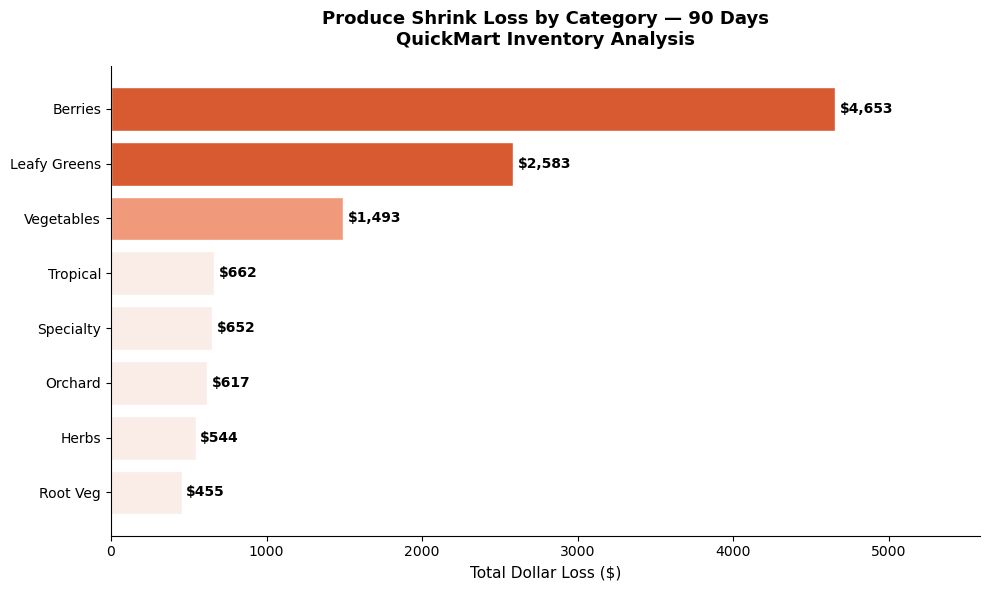

In [7]:
shrink_by_cat = shrink_df.groupby('category')['dollar_loss'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#D85A30' if v > 2000 else '#F0997B' if v > 1000 else '#FAECE7'
          for v in shrink_by_cat.values]

bars = ax.barh(shrink_by_cat.index, shrink_by_cat.values, color=colors, edgecolor='white')

for bar, val in zip(bars, shrink_by_cat.values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Total Dollar Loss ($)', fontsize=11)
ax.set_title('Produce Shrink Loss by Category — 90 Days\nQuickMart Inventory Analysis',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, shrink_by_cat.max() * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('shrink_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

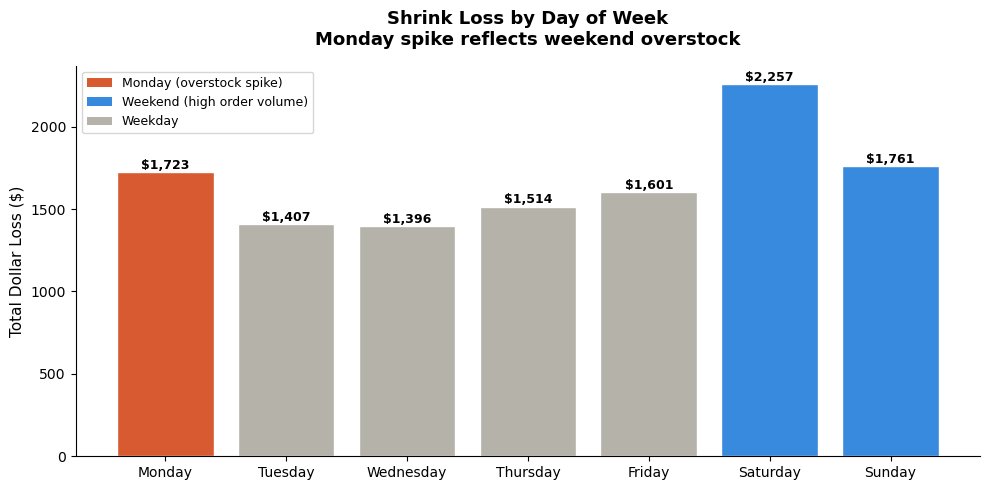

In [8]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

shrink_by_day = (shrink_df.groupby('day_of_week')['dollar_loss']
                 .sum()
                 .reindex(day_order))

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#D85A30' if d == 'Monday' else '#378ADD' if d in ['Saturday','Sunday']
          else '#B4B2A9' for d in day_order]

bars = ax.bar(shrink_by_day.index, shrink_by_day.values, color=colors, edgecolor='white')

for bar, val in zip(bars, shrink_by_day.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Total Dollar Loss ($)', fontsize=11)
ax.set_title('Shrink Loss by Day of Week\nMonday spike reflects weekend overstock',
             fontsize=13, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D85A30', label='Monday (overstock spike)'),
    Patch(facecolor='#378ADD', label='Weekend (high order volume)'),
    Patch(facecolor='#B4B2A9', label='Weekday'),
]
ax.legend(handles=legend_elements, fontsize=9)

plt.tight_layout()
plt.savefig('shrink_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

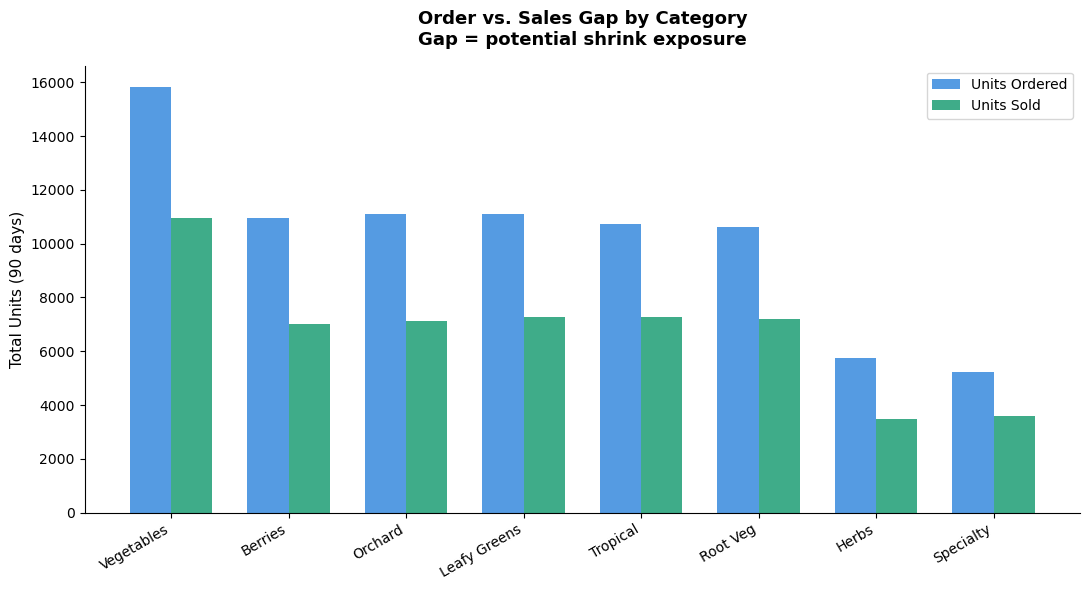

In [9]:
gap_df = (shrink_df.groupby('category')
          .agg(units_ordered=('units_ordered', 'sum'),
               units_sold=('units_sold', 'sum'))
          .assign(units_wasted=lambda x: x['units_ordered'] - x['units_sold'])
          .sort_values('units_wasted', ascending=False))

x = np.arange(len(gap_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(x - width / 2, gap_df['units_ordered'], width,
       label='Units Ordered', color='#378ADD', alpha=0.85)
ax.bar(x + width / 2, gap_df['units_sold'], width,
       label='Units Sold', color='#1D9E75', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(gap_df.index, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Total Units (90 days)', fontsize=11)
ax.set_title('Order vs. Sales Gap by Category\nGap = potential shrink exposure',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('order_vs_sold_gap.png', dpi=150, bbox_inches='tight')
plt.show()